# Assignment #2 — Startup Funding Dataset Analysis
**Course:** AIGC-5000 — Data Analytics  
**Professor:** Maryam Sepehrinour  
**Student:** Bruno Sagayam  

---

## Objective
Analyze the Indian Startup Funding dataset to answer the following six questions:
1. How does the Funding Ecosystem change with respect to Time?
2. What is the General Amount that Startups get in India?
3. Which Kind of Industries are more preferred for Startups?
4. Does Location also play a role in determining the Growth of a Startup?
5. Who plays the main role in Indian Startups Ecosystem?
6. What are the different Types of Funding for Startups?

## 1. Importing Libraries

We begin by importing all necessary libraries. `pandas` and `numpy` handle data loading and manipulation. `matplotlib` and `seaborn` are used for creating visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Loading the Dataset

We load the `startup_funding.csv` file into a pandas DataFrame and perform an initial inspection to understand its structure, column types, and the presence of missing values.

In [2]:
df = pd.read_csv('startup_funding.csv')

print('Shape:', df.shape)
print('\nColumn Names:', list(df.columns))
df.head(5)

Shape: (3044, 10)

Column Names: ['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


## 3. Data Cleaning

Before analysis we need to clean and prepare the data. The key steps are:
- **Date column:** Parse into proper datetime format and extract Year and Month
- **Amount in USD:** Remove commas and convert to float. Non-numeric entries replaced with NaN
- **City names:** Standardize duplicates like Bengaluru → Bangalore
- **Industry names:** Unify inconsistent spellings into one label
- **Funding types:** Consolidate variations into clean categories

In [3]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64


### Step 1 — Parsing the Date Column

We convert the date column from a string format into a proper datetime object. This allows us to extract the year and month from each entry, which is essential for analyzing funding trends over time.

In [4]:
df['Date'] = pd.to_datetime(df['Date dd/mm/yyyy'], format='%d/%m/%Y', errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M')

print(df[['Date dd/mm/yyyy', 'Date', 'Year', 'Month']].head(5))

  Date dd/mm/yyyy       Date    Year    Month
0      09/01/2020 2020-01-09  2020.0  2020-01
1      13/01/2020 2020-01-13  2020.0  2020-01
2      09/01/2020 2020-01-09  2020.0  2020-01
3      02/01/2020 2020-01-02  2020.0  2020-01
4      02/01/2020 2020-01-02  2020.0  2020-01


### Step 2 — Cleaning the Amount in USD Column

The amount column is stored as a string with Indian-style comma formatting. We remove the commas and convert to a float. Entries such as "undisclosed" or "unknown" are replaced with NaN since we cannot estimate specific deal values.

In [5]:
def clean_amount(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ['undisclosed', 'unknown', 'na', 'n/a', '']:
        return np.nan
    val = val.replace(',', '')
    try:
        return float(val)
    except:
        return np.nan

df['Amount_Cleaned'] = df['Amount in USD'].apply(clean_amount)

print(df[['Amount in USD', 'Amount_Cleaned']].head(5))

  Amount in USD  Amount_Cleaned
0  20,00,00,000     200000000.0
1     80,48,394       8048394.0
2   1,83,58,860      18358860.0
3     30,00,000       3000000.0
4     18,00,000       1800000.0


Step 3 — Standardizing City and Industry Names
Some cities appear under multiple spellings in the dataset, for example Bengaluru and Bangalore refer to the same city. We unify these into one consistent label. The same is done for industry names such as ECommerce and E-Commerce.

In [6]:
df['City'] = df['City  Location'].str.strip().str.title()
df['City'] = df['City'].replace({
    'Bengaluru': 'Bangalore',
    'Gurugram': 'Gurgaon',
    'New Delhi': 'Delhi'
})

df['Industry'] = df['Industry Vertical'].str.strip()
df['Industry'] = df['Industry'].replace({
    'ECommerce': 'eCommerce',
    'E-Commerce': 'eCommerce'
})

print(df['City'].value_counts().head(6))
print()
print(df['Industry'].value_counts().head(6))

City
Bangalore    841
Mumbai       567
Delhi        455
Gurgaon      337
Pune         105
Hyderabad     99
Name: count, dtype: int64

Industry
Consumer Internet    941
Technology           478
eCommerce            276
Healthcare            70
Finance               62
Logistics             32
Name: count, dtype: int64


### Step 4 — Standardizing Funding Types

The funding type column contains many variations of the same category due to inconsistent data entry. We consolidate these into clean, unified labels using a custom function.

In [7]:
def normalize_funding(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower().replace('\\n', '').replace('\n', '')
    if 'seed' in val and 'angel' in val:
        return 'Seed / Angel Funding'
    if 'seed' in val:
        return 'Seed Funding'
    if 'private equity' in val or 'privateequity' in val:
        return 'Private Equity'
    if 'debt' in val:
        return 'Debt Funding'
    if 'series a' in val or 'pre-series a' in val:
        return 'Series A'
    if 'series b' in val:
        return 'Series B'
    if 'series c' in val:
        return 'Series C'
    if 'series d' in val:
        return 'Series D'
    return val.title()

df['FundingType'] = df['InvestmentnType'].apply(normalize_funding)

print(df['FundingType'].value_counts().head(8))

FundingType
Seed Funding            1401
Private Equity          1361
Seed / Angel Funding     138
Series A                  33
Debt Funding              29
Series B                  21
Series C                  14
Series D                  12
Name: count, dtype: int64


---
## Question 1 — How Does the Funding Ecosystem Change with Respect to Time?

To answer this question we analyze the number of funding deals and the total amount funded per year. A rising number of deals over time indicates a growing startup ecosystem, while changes in total funding show how investor confidence evolves. We use a dual-view approach: a bar chart for deal count per year and a line chart for total funding per year.

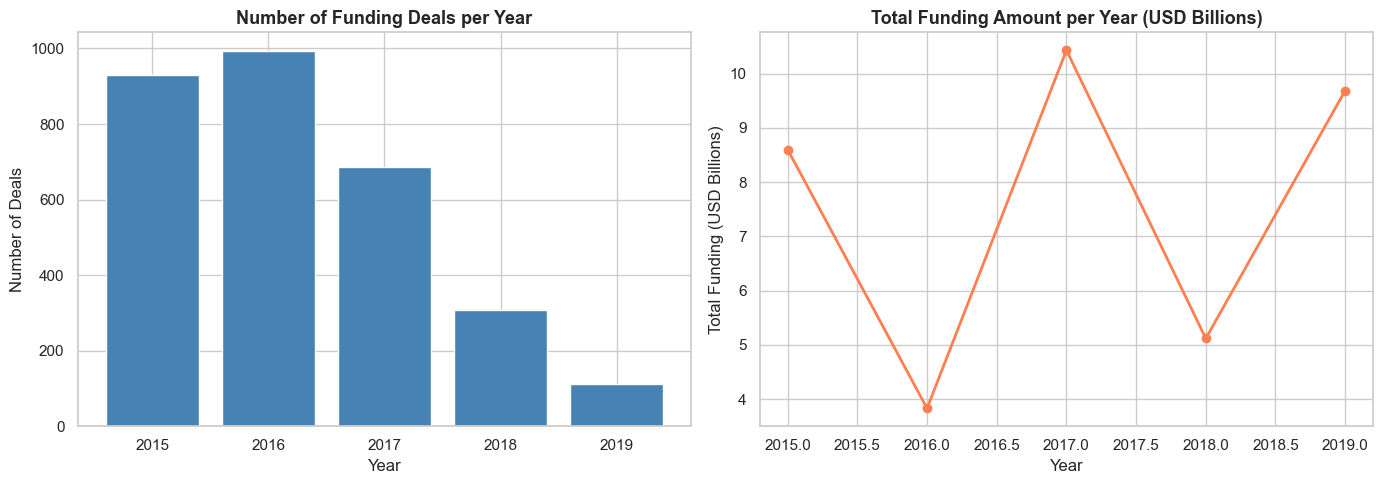

In [8]:
yearly_deals = df.groupby('Year').size().reset_index(name='Deal Count')
yearly_funding = df.groupby('Year')['Amount_Cleaned'].sum().reset_index(name='Total Funding (USD)')

yearly = yearly_deals.merge(yearly_funding, on='Year').dropna()
yearly = yearly[yearly['Year'].between(2015, 2019)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['Year'], yearly['Deal Count'], color='steelblue', edgecolor='white')
axes[0].set_title('Number of Funding Deals per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Deals')

axes[1].plot(yearly['Year'], yearly['Total Funding (USD)'] / 1e9, marker='o', color='coral', linewidth=2)
axes[1].set_title('Total Funding Amount per Year (USD Billions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Funding (USD Billions)')

plt.tight_layout()
plt.show()

**Insight:** The Indian startup ecosystem peaked in deal volume in 2015–2016, with nearly 1,000 funding deals in 2016 alone. After 2016 the number of deals declined steadily, however the total funding amount spiked in 2017 despite fewer deals. This indicates that while fewer startups received funding, investors became more selective and committed larger amounts to high-potential startups — a sign of a maturing ecosystem.

---
## Question 2 — What is the General Amount that Startups Get in India?

Here we look at the distribution of funding amounts. Since there are extreme outliers — a few very large deals — we examine both the median and the mean. The median is more reliable here because it is resistant to outliers. A histogram and a funding bracket chart help visualize the spread across different funding sizes.

In [9]:
amount_data = df['Amount_Cleaned'].dropna()

print('=== Funding Amount Statistics (USD) ===')
print(f'Count of Disclosed Deals : {len(amount_data):,}')
print(f'Minimum                  : ${amount_data.min():,.0f}')
print(f'Maximum                  : ${amount_data.max():,.0f}')
print(f'Mean (Average)           : ${amount_data.mean():,.0f}')
print(f'Median                   : ${amount_data.median():,.0f}')
print(f'25th Percentile          : ${amount_data.quantile(0.25):,.0f}')
print(f'75th Percentile          : ${amount_data.quantile(0.75):,.0f}')

=== Funding Amount Statistics (USD) ===
Count of Disclosed Deals : 2,065
Minimum                  : $16,000
Maximum                  : $3,900,000,000
Mean (Average)           : $18,429,897
Median                   : $1,700,000
25th Percentile          : $470,000
75th Percentile          : $8,000,000


We visualize the distribution of funding amounts using a histogram on a log scale to handle the wide range of values. A funding bracket chart groups deals into ranges for a clearer picture of where most startups fall.

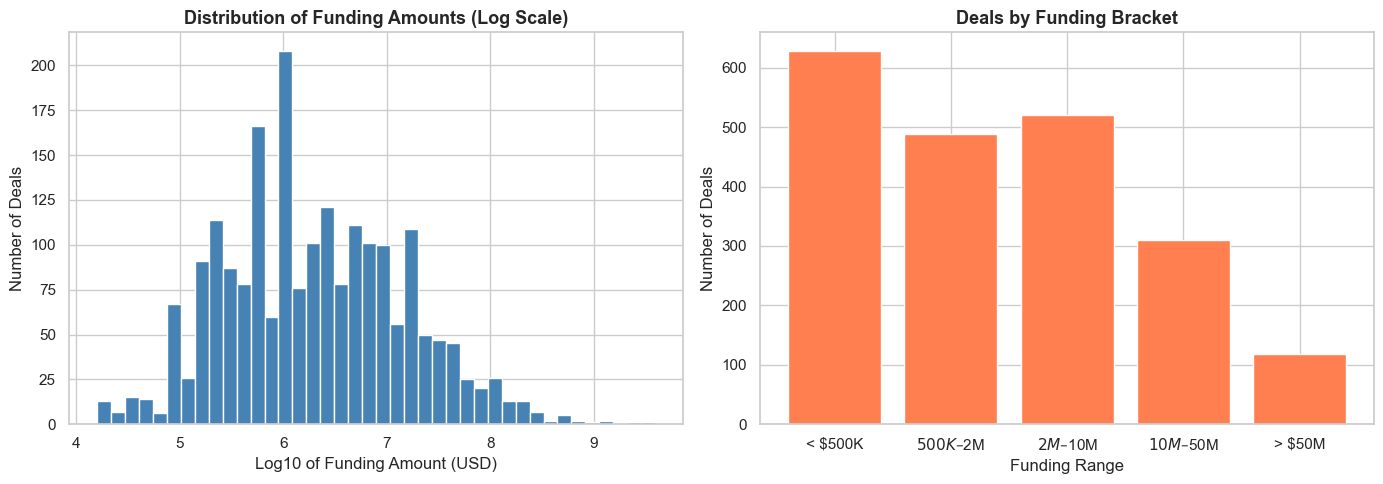

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log10(amount_data + 1), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Funding Amounts (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log10 of Funding Amount (USD)')
axes[0].set_ylabel('Number of Deals')

funding_brackets = pd.cut(
    amount_data,
    bins=[0, 500000, 2000000, 10000000, 50000000, float('inf')],
    labels=['< $500K', '$500K–$2M', '$2M–$10M', '$10M–$50M', '> $50M']
)
bracket_counts = funding_brackets.value_counts().sort_index()
axes[1].bar(bracket_counts.index, bracket_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Deals by Funding Bracket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Funding Range')
axes[1].set_ylabel('Number of Deals')

plt.tight_layout()
plt.show()

**Insight:** The median funding amount of 1.7 million USD is far more representative of a typical Indian startup than the mean of 18 million USD, which is heavily distorted by a small number of very large deals. The majority of startups raise less than 500K USD, confirming that the Indian startup ecosystem is primarily driven by early stage, small-scale investments.

---
## Question 3 — Which Kind of Industries are More Preferred for Startups?

We count the number of funded startups per industry vertical to identify which sectors attract the most investor activity. The top 10 industries are visualized using a horizontal bar chart for easy comparison.

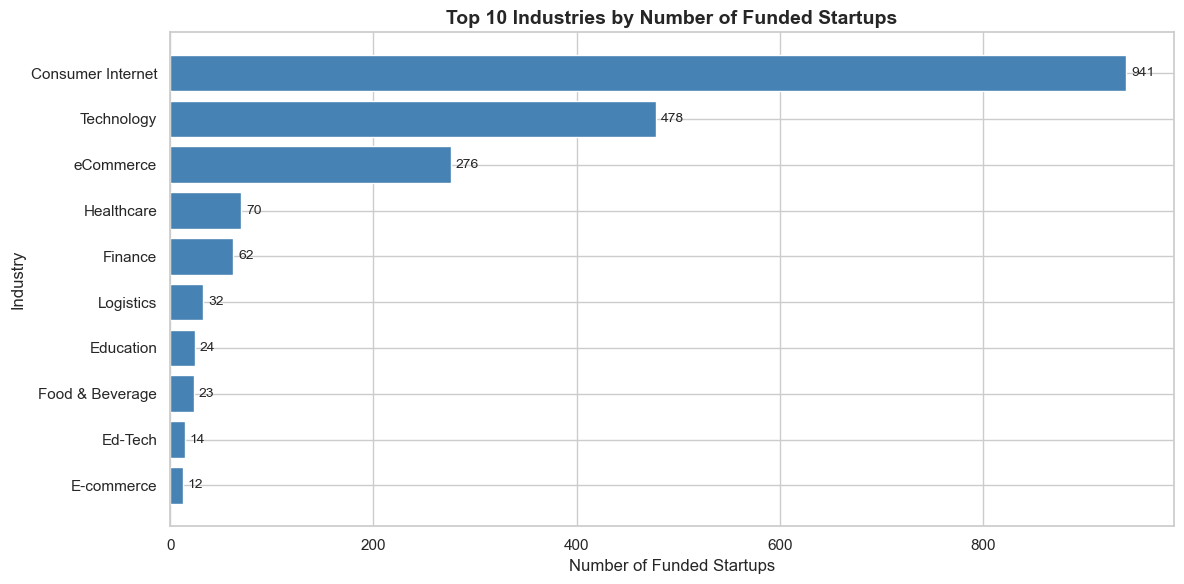

In [12]:
top_industries = df['Industry'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_industries.index[::-1], top_industries.values[::-1], color='steelblue', edgecolor='white')
plt.title('Top 10 Industries by Number of Funded Startups', fontsize=14, fontweight='bold')
plt.xlabel('Number of Funded Startups')
plt.ylabel('Industry')
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())), va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** Consumer Internet and Technology dominate the Indian startup landscape by a wide margin, together accounting for nearly half of all funded deals. eCommerce ranks third, reflecting the rapid growth of online retail in India. Healthcare, Finance, and Logistics are also emerging as attractive sectors for investors.

---
## Question 4 — Does Location Play a Role in Determining the Growth of a Startup?

We analyze the geographical distribution of funded startups by city. Cities with more funding activity tend to have stronger startup ecosystems due to better infrastructure, talent pools, and investor networks. We visualize both deal count and total funding by city.

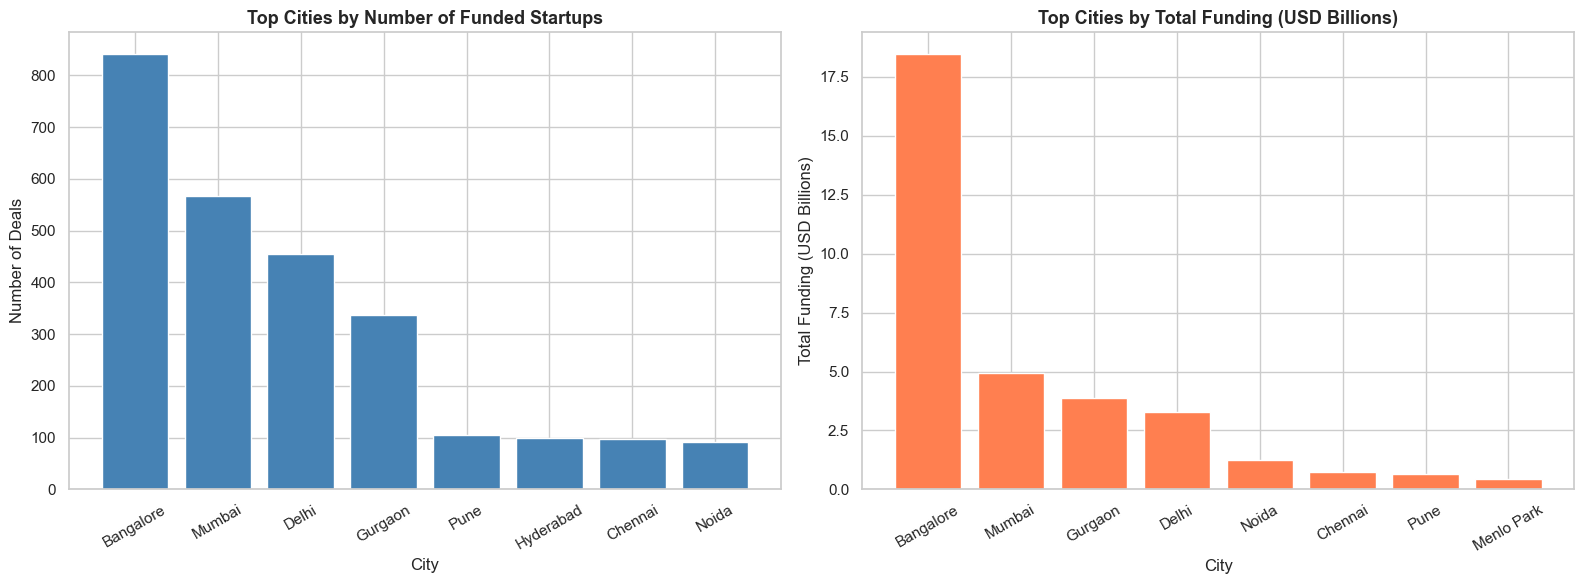

In [13]:
top_cities_count = df['City'].value_counts().head(8)
top_cities_amount = df.groupby('City')['Amount_Cleaned'].sum().nlargest(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(top_cities_count.index, top_cities_count.values, color='steelblue', edgecolor='white')
axes[0].set_title('Top Cities by Number of Funded Startups', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of Deals')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(top_cities_amount.index, top_cities_amount.values / 1e9, color='coral', edgecolor='white')
axes[1].set_title('Top Cities by Total Funding (USD Billions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Funding (USD Billions)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Insight:** Location plays a significant role in startup growth. Bangalore dominates as India's Silicon Valley, leading in both deal volume and total funding received at nearly 18 billion USD. Mumbai and Delhi follow as major financial and commercial hubs. Startups located in these top cities have substantially greater access to investors, talent pools, and infrastructure which contributes directly to their growth potential.

---
## Question 5 — Who Plays the Main Role in the Indian Startups Ecosystem?

We identify the most active investors in the Indian startup ecosystem. Since multiple investors often co-invest in a single deal, we split the Investors Name column by comma and count each investor's individual appearances across all deals.

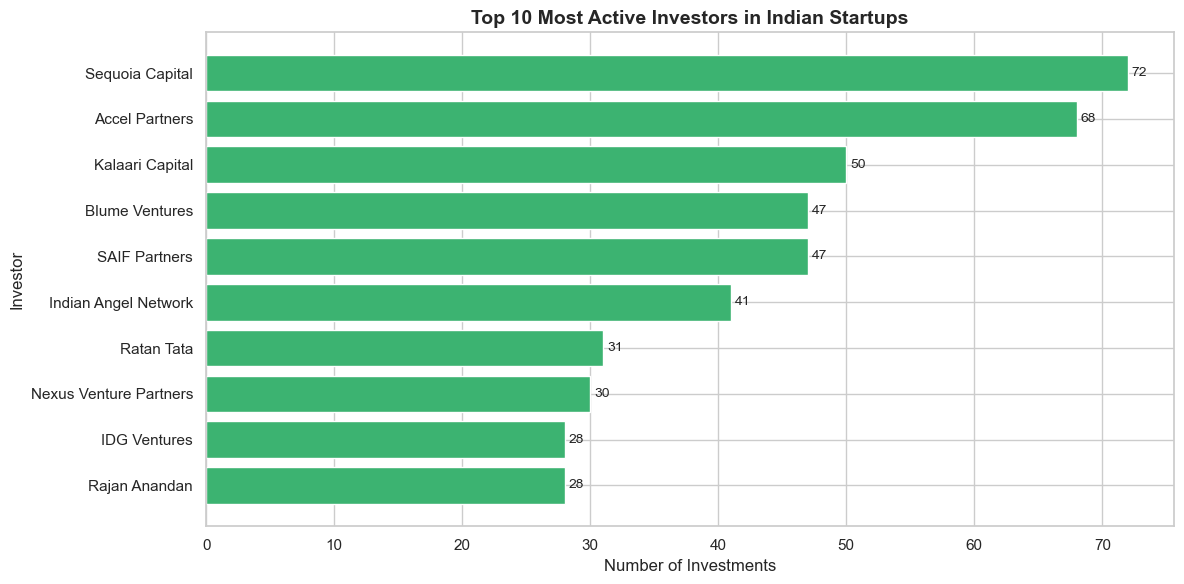

In [14]:
all_investors = (
    df['Investors Name']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

all_investors = all_investors[~all_investors.str.lower().isin(['undisclosed investors', 'undisclosed investor', ''])]

top_investors = all_investors.value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_investors.index[::-1], top_investors.values[::-1], color='mediumseagreen', edgecolor='white')
plt.title('Top 10 Most Active Investors in Indian Startups', fontsize=14, fontweight='bold')
plt.xlabel('Number of Investments')
plt.ylabel('Investor')
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())), va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** Sequoia Capital and Accel Partners are the most active investors, reflecting the dominance of global venture capital firms in India's startup ecosystem. Notably, Ratan Tata stands out as the only prominent individual angel investor in the top 10. Indian-origin firms like Kalaari Capital, SAIF Partners, and Blume Ventures also play a crucial role in nurturing early stage startups.

---
## Question 6 — What are the Different Types of Funding for Startups?

We examine the distribution of funding types to understand which mechanisms are most commonly used by Indian startups to raise capital. We use both a pie chart for proportional overview and a bar chart for exact counts.

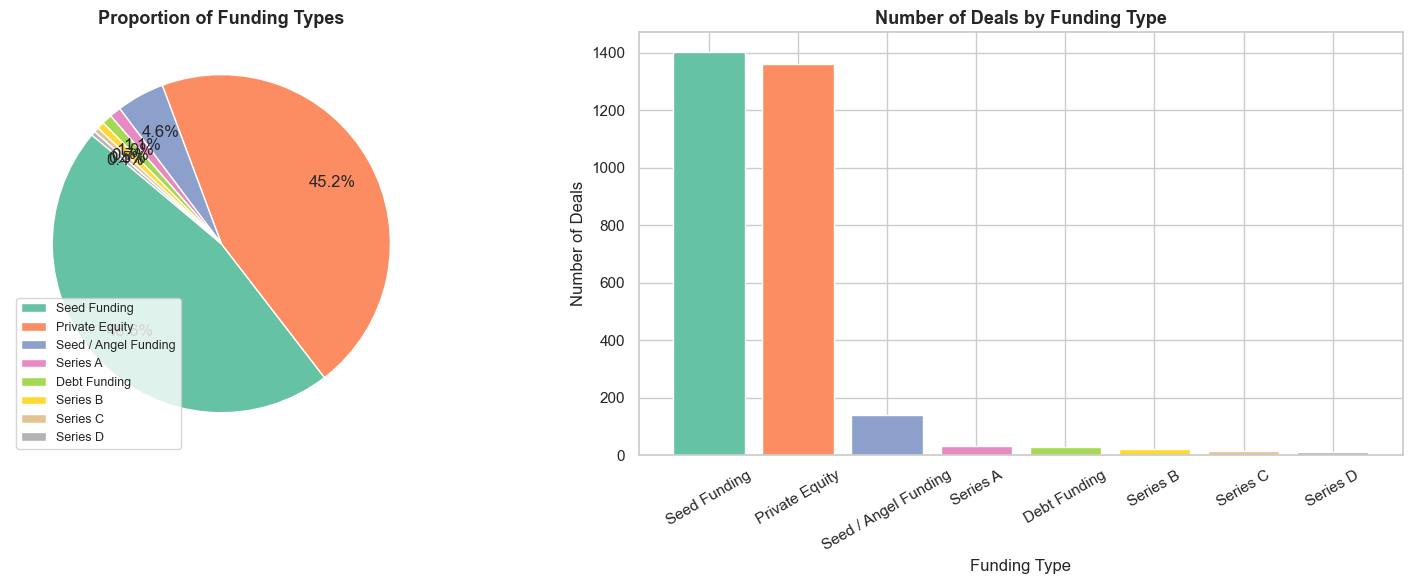

In [16]:
main_types = ['Seed Funding', 'Private Equity', 'Seed / Angel Funding',
              'Series A', 'Debt Funding', 'Series B', 'Series C', 'Series D']
funding_counts = df[df['FundingType'].isin(main_types)]['FundingType'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(
    funding_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    colors=sns.color_palette('Set2', len(funding_counts))
)
axes[0].legend(
    funding_counts.index,
    loc='lower left',
    fontsize=9
)
axes[0].set_title('Proportion of Funding Types', fontsize=13, fontweight='bold')

axes[1].bar(funding_counts.index, funding_counts.values,
            color=sns.color_palette('Set2', len(funding_counts)), edgecolor='white')
axes[1].set_title('Number of Deals by Funding Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Funding Type')
axes[1].set_ylabel('Number of Deals')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Insight:** Seed Funding and Private Equity together account for over 90% of all funding deals in India. This indicates that the Indian startup ecosystem is primarily driven by early stage seed investments and later stage private equity rounds. Series A, B, C and D funding are much less frequent, suggesting that many startups do not reach the scale required for institutional growth stage rounds.

---
## Summary of Findings

| Question | Key Finding |
|----------|-------------|
| 1. Funding over Time | Deal volume peaked in 2015-2016 and declined as the ecosystem matured |
| 2. General Amount | Median deal size is 1.7 million USD, majority of deals fall below 500K USD |
| 3. Preferred Industries | Consumer Internet and Technology lead, eCommerce is third |
| 4. Role of Location | Bangalore, Mumbai and Delhi dominate — location strongly influences startup growth |
| 5. Key Ecosystem Players | Sequoia Capital and Accel Partners are the most active investors |
| 6. Types of Funding | Seed Funding and Private Equity dominate at over 90% of all deals |